In [1]:
!pip install pennylane qiskit qiskit_machine_learning qiskit_aer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 46.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 22.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 79.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 73.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 52.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 52.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 85.8 MB/s eta 0:00:00:00:0100:01


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import pennylane as qml
from pennylane import numpy as np_qml

from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_aer.primitives import Estimator
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_aer import Aer


torch.manual_seed(42)
np.random.seed(42)
np_qml.random.seed(42)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Load data
در این قسمت داده ها را لود می کنیم و اندازه آن را به ۲۸ در ۲۸ تغییر می دهیم. سپس داده های با برچسب ۳ و ۵ را فیلتر می کنیم و برچسب آنها هم ۰ و ۱ می کنیم. سپس ۵۰۰ تا نمونه برای آموزش و ۱۰۰ نمونه برای تست انتخاب می کنیم که زمان آموزش زیاد نشود.

In [3]:
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
])

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

def filter_3_and_5(dataset):
    idx = (dataset.targets == 3) | (dataset.targets == 5)
    dataset.targets = dataset.targets[idx]
    dataset.data = dataset.data[idx]
    
    dataset.targets = torch.where(dataset.targets == 3, 0, 1)
    return dataset

# Filter data
train_data = filter_3_and_5(train_data)
test_data = filter_3_and_5(test_data)

# Reduce dataset size for quick training (Optional, based on paper's small scale exp)
# Or keep full if you have time. Here we keep a smaller subset for testing code.
n_samples = 500
train_data.data = train_data.data[:n_samples]
train_data.targets = train_data.targets[:n_samples]
test_data.data = test_data.data[:100]
test_data.targets = test_data.targets[:100]

# Create DataLoaders
# Batch size is 1 for quantum simulation efficiency usually, or small like 4
batch_size = 4 
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print(f"Train size: {len(train_data)}")
print(f"Test size: {len(test_data)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 58.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.77MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.67MB/s]

Train size: 500
Test size: 100


## Static Quantum filter

مدار ۴ کیوبیتی خود را مطابق مقاله تعریف می کنیم.

In [4]:
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

در این قسمت فیلتر کوانتومی خود را می سازیم به این صورت که ابتدا مقدار پیکسل را به صورت زاویه محور وای کد می کنیم و سپس مدار تصادفی ولی ثاب که ترکیبی از گیت های چرخشی به مقدار لیست تتا (که تصادفی مشخص شده و ثابت است) و گیت های نقیض شرطی اعمال می کنیم و سپس مطابق مقاله با پااولی زد اندازه می گیریم.

$$|\psi_{init}\rangle = \bigotimes_{i=0}^{3} R_Y(\pi \phi_i) |0\rangle$$

In [5]:
@qml.qnode(dev)
def quantum_filter_circuit(phi, theta_list):
    for i in range(n_qubits):
        qml.RY(np_qml.pi * phi[i], wires=i)
    
    qml.templates.RandomLayers(theta_list, wires=list(range(n_qubits)))
    
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

ابتدا پارامتر های تصادفی را تعیین می کنیم. طبیعی است که این مقدار حداکثر تا ۲ پی که یک دور دایره مثلثاتی است مقدار می گیرد.

در این مرحله که مدار را طراحی کرده این و داریم مانند مدار کانولوشتی با آن رفتار می کنیم و با فاصله ۲ تا ۲ تا روی تصویر صدا می زنیم مشخص است که در هر قسمت ۴ مقدار از مدار خروجی می گیریم و با توجه به ابعاد تصویر ورودی خروجی به  شکل ۱۴ در ۱۴ در ۴ است.

In [6]:
n_layers = 1
rand_params = np_qml.random.uniform(high=2 * np_qml.pi, size=(n_layers, n_qubits))

def quanv_layer(image):
    # input shape: (28, 28) -> output shape (14, 14, 4) due to stride 2
    q_out = np.zeros((14, 14, 4))
    
    for j in range(0, 28, 2):
        for k in range(0, 28, 2):
            patch = image[j:j+2, k:k+2]
            phi = patch.flatten()
            
            q_results = quantum_filter_circuit(phi, rand_params)
            
            q_out[j//2, k//2] = q_results
            
    return q_out

برای این که تصویر را به مدار بدهیم باید مقدار پیکسل ها را نرمال و بین ۰ و ۱ کنیم سپس مدار را صدا می زنیم و در نهایت ساختار خروجی را درست می کنیم و در لیست ذخیره می کنیم.

In [7]:
def pre_process_dataset(dataset):
    new_data = []
    for img in dataset.data:
        img_float = img.numpy() / 255.0
        
        q_features = quanv_layer(img_float)
        
        q_features = q_features.transpose(2, 0, 1)
        new_data.append(q_features)
    
    return torch.tensor(np.array(new_data), dtype=torch.float32)

در این قسمت مدار فیلتر را حساب می کنیم و در یک دیتا ست و دیتا لودر ذخیره می کنیم.

In [8]:
train_data_quanv = pre_process_dataset(train_data)
test_data_quanv = pre_process_dataset(test_data)

train_dataset_new = TensorDataset(train_data_quanv, train_data.targets)
test_dataset_new = TensorDataset(test_data_quanv, test_data.targets)

train_loader = DataLoader(train_dataset_new, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset_new, batch_size=4, shuffle=False)

print(f"New data shape: {train_data_quanv.shape}")

New data shape: torch.Size([500, 4, 14, 14])


## Create qnn classifier
عناصر این قسمت در کتابخانه آماده است تنها کافیست که پارامتر های آن را تنظیم کنیم. همانطور که در مقاله گفته شد ۲ کیوبیت داریم و همچنین بخش نقشه ویژگی یکبار تکرار ندارد و بخش 

Real Amp

برای این که عمق ۵ شود عملا باید ۲ بار تکرار کنیم طبق سند کتابخانه.
در نهایت ۲ بخش مدار را به هم متصل می کنیم و با استفاده از پااولی زد مقدار کیوبیت اول و به روش معمولی کیوبیت دوم را ندازه می گیریم. در آخر مدا را می سازیم و بر می گردانیم.

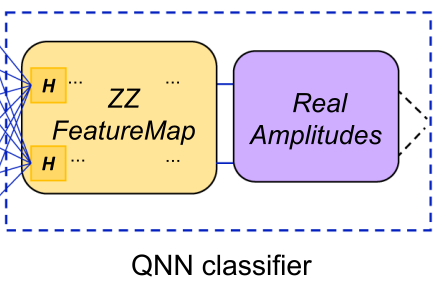

In [9]:
def create_qnn_classifier():
    num_qubits = 2
    
    feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=1)
    
    ansatz = RealAmplitudes(num_qubits=num_qubits, reps=2, entanglement='linear')
    
    qc = QuantumCircuit(num_qubits)
    qc.compose(feature_map, inplace=True)
    qc.compose(ansatz, inplace=True)
    
    observable = SparsePauliOp.from_list([("IZ", 1)]) 
    
    qnn = EstimatorQNN(
        circuit=qc,
        input_params=feature_map.parameters,
        weight_params=ansatz.parameters,
        observables=[observable],
        input_gradients=True # for backpropagation!
    )
    return qnn

qnn_estimator = create_qnn_classifier()

/tmp/ipykernel_105/2019715200.py:4: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=1)
/tmp/ipykernel_105/2019715200.py:6: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=num_qubits, reps=2, entanglement='linear')
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


## Create classic cnn

این قسمت ساده است مطابق طراحی مقاله شبکه را می سازیم ۲ لایه کانولوشنی با مکس پول و ۲ لایه تماما متصل و سپس بخش کوانتومی را صدا می زنیم نتیجه را می گیریم و با اعمال بایاس دسته بندی می کنیم.
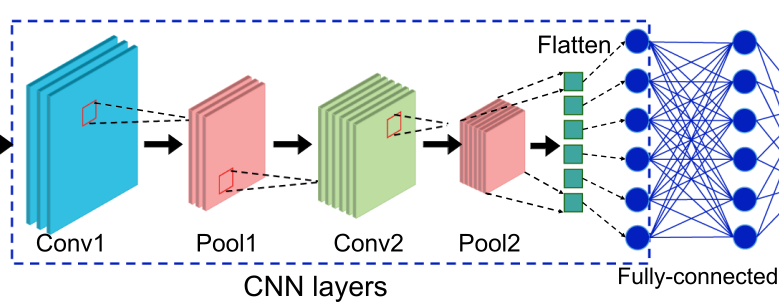

In [10]:
class QCQ_CNN_Model(nn.Module):
    def __init__(self, qnn):
        super().__init__()
        
        self.conv1 = nn.Conv2d(in_channels=4, out_channels=16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.fc = nn.Linear(32 * 3 * 3, 2) 
        
        self.qnn_layer = TorchConnector(qnn_estimator)
        
        self.bias = nn.Parameter(torch.tensor([0.0]))

    def forward(self, x):
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        
        x = x.view(x.shape[0], -1)
        
        x = self.fc(x)
        
        x = self.qnn_layer(x) 
        
        x = x + self.bias
        
        return x

model = QCQ_CNN_Model(qnn_estimator)
print(model)

QCQ_CNN_Model(
  (conv1): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=288, out_features=2, bias=True)
  (qnn_layer): TorchConnector()
)


## Train

این قسمت نیز ساده است مانند هر مدل دیگری اپتیمایزر و تابع لاس را تعریف می کنیم و در مسیر رو به جلو را میریم و سپس لاس را حساب می کنیم و سپس گرادیان را حساب می کنیم و در آخر آن را به اپتیمایزر می دهیم.

Training 10 epochs...
Epoch 1/10 	 Loss: 0.2586
Epoch 2/10 	 Loss: 0.1046
Epoch 3/10 	 Loss: 0.0439
Epoch 4/10 	 Loss: 0.0413
Epoch 5/10 	 Loss: 0.0239
Epoch 6/10 	 Loss: 0.0167
Epoch 7/10 	 Loss: 0.0136
Epoch 8/10 	 Loss: 0.0163
Epoch 9/10 	 Loss: 0.0121
Epoch 10/10 	 Loss: 0.0127


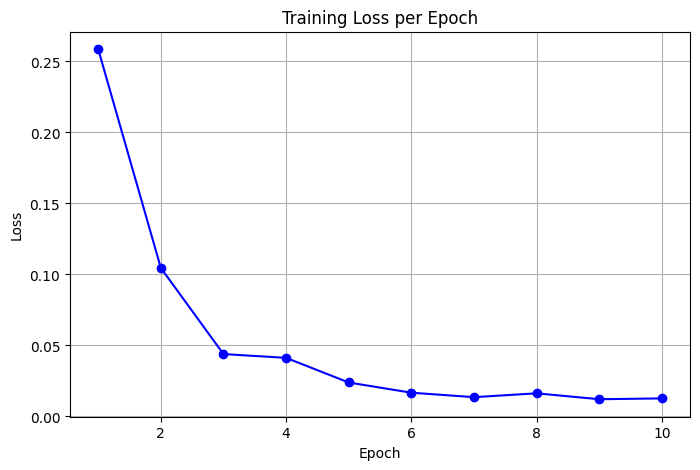

In [11]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_func = nn.MSELoss()

epochs = 10  
loss_list = []

print(f"Training {epochs} epochs...")
model.train() 

for epoch in range(epochs):
    total_loss = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        
        output = model(data)
        
        target = target.float().view(-1, 1)
        
        loss = loss_func(output, target)
        
        loss.backward()
        
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_loss = total_loss / len(train_loader)
    loss_list.append(avg_loss)
    
    print(f"Epoch {epoch+1}/{epochs} \t Loss: {avg_loss:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), loss_list, marker='o', linestyle='-', color='b')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

## Test

In [12]:
model.eval() 
correct = 0
with torch.no_grad():
    for data, target in test_loader:
        output = model(data)
        
        predicted = (output > 0.5).float().view(-1)
        
        correct += (predicted == target).sum().item()

accuracy = correct / len(test_data)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 98.00%


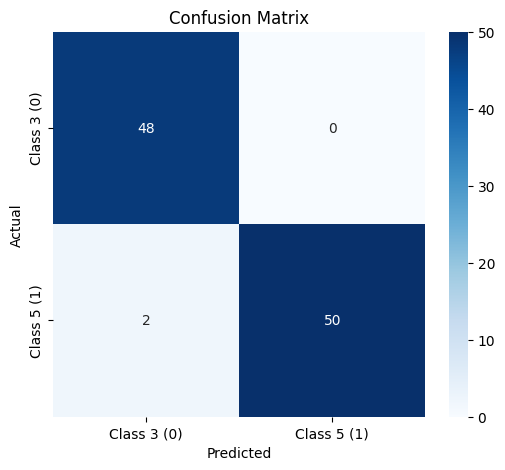

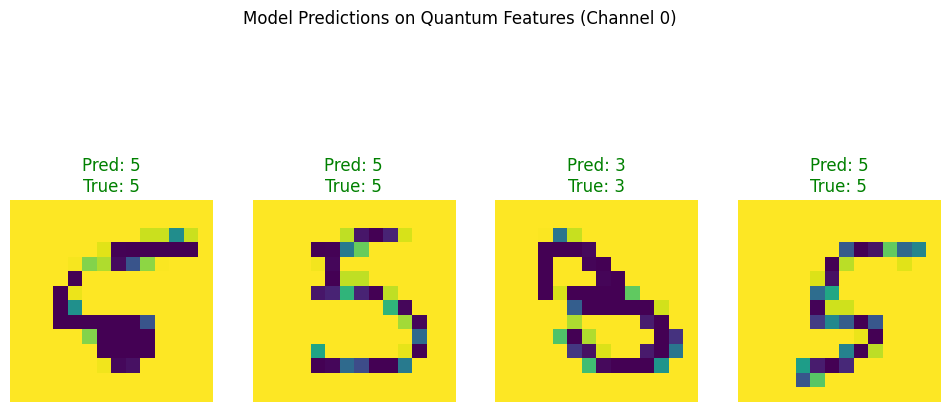

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:
        output = model(data)
        preds = (output > 0.5).float().view(-1)
        
        all_preds.extend(preds.numpy())
        all_targets.extend(target.numpy())

cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Class 3 (0)', 'Class 5 (1)'], 
            yticklabels=['Class 3 (0)', 'Class 5 (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

data_iter = iter(test_loader)
images_quanv, labels = next(data_iter)
outputs = model(images_quanv)
predicted = (outputs > 0.5).float().view(-1)

plt.figure(figsize=(12, 6))
for i in range(4):
    ax = plt.subplot(1, 4, i + 1)
    
    img_to_show = images_quanv[i][0].numpy() 
    
    plt.imshow(img_to_show, cmap='viridis')
    
    pred_label = "5" if predicted[i].item() == 1 else "3"
    true_label = "5" if labels[i].item() == 1 else "3"
    
    col = 'green' if pred_label == true_label else 'red'
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=col)
    plt.axis('off')

plt.suptitle("Model Predictions on Quantum Features (Channel 0)")
plt.show()